# Transfer learning: Feature Extraction

Transfer learning is leveraging a working model's existing architecture and learning patterns for out own problem

## Downloading and becoming one with the data

In [3]:
# Download the data
#!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

In [5]:
# Get data (10% of food classes from Food101)\
import zipfile

# Unzip the downloaded file 
zip_ref = zipfile.ZipFile("10_food_classes_10_percent.zip")
zip_ref.extractall()
zip_ref.close()

In [11]:
# How many images in each folder?
import os

#Walk through data directory and list number of files
for dirpath, dirnames, filenames in os.walk("10_food_classes_10_percent"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

There are 2 directories and 0 images in 10_food_classes_10_percent
There are 10 directories and 0 images in 10_food_classes_10_percent/train
There are 0 directories and 75 images in 10_food_classes_10_percent/train/fried_rice
There are 0 directories and 75 images in 10_food_classes_10_percent/train/hamburger
There are 0 directories and 75 images in 10_food_classes_10_percent/train/chicken_curry
There are 0 directories and 75 images in 10_food_classes_10_percent/train/sushi
There are 0 directories and 75 images in 10_food_classes_10_percent/train/ramen
There are 0 directories and 75 images in 10_food_classes_10_percent/train/ice_cream
There are 0 directories and 75 images in 10_food_classes_10_percent/train/chicken_wings
There are 0 directories and 75 images in 10_food_classes_10_percent/train/steak
There are 0 directories and 75 images in 10_food_classes_10_percent/train/grilled_salmon
There are 0 directories and 75 images in 10_food_classes_10_percent/train/pizza
There are 10 director

### Create data loaders (preparing the data)

Use the ImageDataGenerator class to load in out images in batches

In [53]:
# Setup data inputs 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 5

train_dir = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

print("Training data")
train_data_10_percent = train_datagen.flow_from_directory(train_dir,
                                                         target_size=IMAGE_SIZE,
                                                         batch_size=BATCH_SIZE,
                                                         class_mode="categorical")
print("Test data")
test_data = train_datagen.flow_from_directory(test_dir,
                                                         target_size=IMAGE_SIZE,
                                                         batch_size=BATCH_SIZE,
                                                         class_mode="categorical")

Training data
Found 750 images belonging to 10 classes.
Test data
Found 2500 images belonging to 10 classes.


## Setting up callbacks (things that run whilst our model trains)

Callbacks are extra functionalities you can add to your models to be performed during or after training. Some of the most popular are:
* Tracking experiments with the Tensorboard callback
* Model checkpoint with the ModelCheckpoint callback
* Stopping a model from training(before it trains too long and overfits) with the EarlyStopping callback.

In [80]:
import datetime

def create_tensorboard_callback(dir_name, experiment_name):
    log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M")
    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)  # capital B
    print(f"Saving Tensorflow log files to: {log_dir}")
    return tensorboard_callback

## Creating models using Tensorflow Hub

In [67]:
import tensorflow_hub as hub
from tensorflow.keras import layers

In [132]:
from keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

PREPROCESSING_REGISTRY = {
    "resnet_v2_101": resnet_preprocess,
    "xception":      keras.applications.xception.preprocess_input,
    "efficientnet":  efficientnet_preprocess,
}

def create_model(model_name, num_classes=10, image_size=(224, 224)):
    if model_name not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model '{model_name}'. Choose from: {list(MODEL_REGISTRY.keys())}")

    base_model = MODEL_REGISTRY[model_name](
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(*image_size, 3)
    )
    base_model.trainable = False

    preprocess = PREPROCESSING_REGISTRY[model_name]

    model = keras.Sequential([
        layers.Input(shape=(*image_size, 3)),
        layers.Lambda(preprocess, name="preprocessing"),
        base_model,
        layers.Dense(num_classes, activation="softmax", name="output_layer")
    ])

    return model

In [122]:
# Create Resnet model
resnet_model = create_model("resnet_v2_101")
resnet_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet101v2 (Functional)        │ (None, 2048)           │    42,626,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,647,050 (162.69 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 42,626,560 (162.61 MB)

In [133]:
# Create Efficientnet model
efficientnet_model = create_model("efficientnet")
efficientnet_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessing (Lambda)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,197 (16.73 MB)

 Trainable params: 333,066 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [118]:
# Plot the validation and training curves separetly 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random


def plot_loss_curves(history):
    """
    Returns separate loss curves and validation metrics.
    """
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]

    epochs = range(len(history.history["loss"])) 

    # Plot model loss 
    plt.plot(epochs, loss, label="training loss")
    plt.plot(epochs, val_loss, label="validation loss")
    plt.title("Loss")
    plt.xlabel("epochs")
    plt.legend()

    # Plot model accuracy 
    plt.figure()
    plt.plot(epochs, accuracy, label="training accuracy")
    plt.plot(epochs, val_accuracy, label="validation accuracy")
    plt.title("Accuracy")
    plt.xlabel("epochs")
    plt.legend()

In [124]:
# Compile resnet model
resnet_model.compile(loss="categorical_crossentropy",
                    optimizer="adam",
                    metrics=["accuracy"])

In [125]:
resnet_history = resnet_model.fit(
    train_data_10_percent,
    epochs=10,
    steps_per_epoch=len(train_data_10_percent),
    validation_data=test_data,
    callbacks=[create_tensorboard_callback(
        dir_name="tensorflow_hub",
        experiment_name="resnet_v2_50"
    )]
)

Saving Tensorflow log files to: tensorflow_hub/resnet_v2_50/20260321-0034
Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 24s 657ms/step - accuracy: 0.3293 - loss: 2.0628 - val_accuracy: 0.6052 - val_loss: 1.2410
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 341ms/step - accuracy: 0.7387 - loss: 0.9092 - val_accuracy: 0.7148 - val_loss: 0.8873
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 339ms/step - accuracy: 0.8107 - loss: 0.6328 - val_accuracy: 0.7392 - val_loss: 0.7987
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 346ms/step - accuracy: 0.8867 - loss: 0.4648 - val_accuracy: 0.7644 - val_loss: 0.7360
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 338ms/step - accuracy: 0.9200 - loss: 0.3649 - val_accuracy: 0.7708 - val_loss: 0.7139
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 338ms/step - accuracy: 0.9360 - loss: 0.2915 - val_accuracy: 0.7660 - val_loss: 0.6987
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 338ms/step - accuracy: 0.9560 - loss: 0.2446 - val_accuracy: 0.7780 - val_loss: 0.6870
Epoch 8/10
24/24 ━━━━━━━━━━━━

In [134]:
# Compile efficientnet model
efficientnet_model.compile(loss="categorical_crossentropy",
                    optimizer="adam",
                    metrics=["accuracy"])

In [135]:
efficientnet_history = efficientnet_model.fit(
    train_data_10_percent,
    epochs=10,
    steps_per_epoch=len(train_data_10_percent),
    validation_data=test_data,
    callbacks=[create_tensorboard_callback(
        dir_name="tensorflow_hub",
        experiment_name="efficientnet"
    )]
)

Saving Tensorflow log files to: tensorflow_hub/efficientnet/20260321-0041
Epoch 1/10


2026-03-21 00:41:37.141110: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-21 00:41:37.826969: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_11077', 24 bytes spill stores, 24 bytes spill loads

2026-03-21 00:41:37.929685: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_11077', 520 bytes spill stores, 520 bytes spill loads



 3/24 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0833 - loss: 2.6171 

2026-03-21 00:41:44.008376: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_10867', 8 bytes spill stores, 8 bytes spill loads



23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.0939 - loss: 2.7776

2026-03-21 00:41:52.004568: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2110', 16 bytes spill stores, 16 bytes spill loads



24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 770ms/step - accuracy: 0.1013 - loss: 2.8825 - val_accuracy: 0.1000 - val_loss: 2.3374
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.1040 - loss: 2.8877 - val_accuracy: 0.1000 - val_loss: 2.3348
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.1053 - loss: 2.8680 - val_accuracy: 0.1000 - val_loss: 2.3243
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.1000 - loss: 2.7946 - val_accuracy: 0.1000 - val_loss: 2.3179
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.0907 - loss: 2.7518 - val_accuracy: 0.1000 - val_loss: 2.3098
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.1013 - loss: 2.7570 - val_accuracy: 0.1000 - val_loss: 2.3060
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.1000 - loss: 2.7339 - val_accuracy: 0.1000 - val_loss: 2.3059
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - accuracy: 0.0947 - loss: 2.7199 - val_accuracy: 0.1000 - val

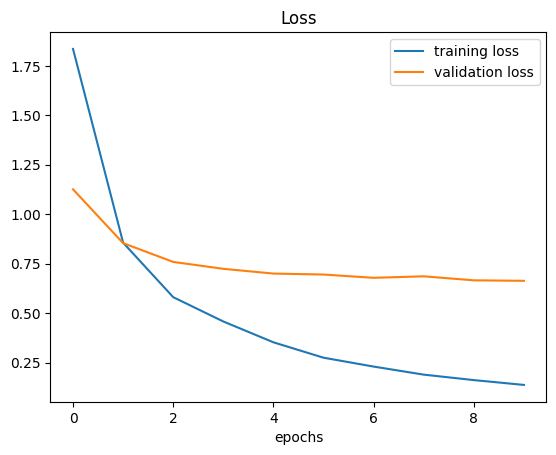

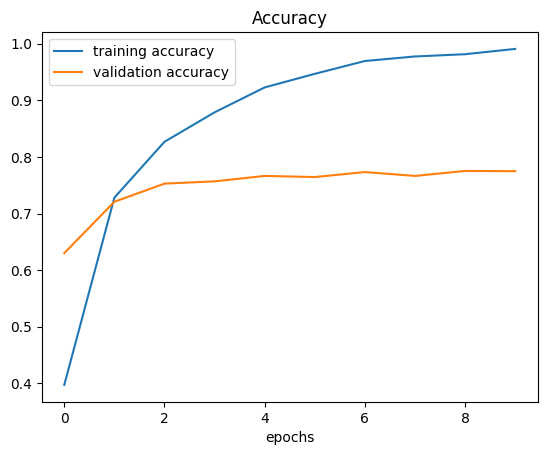

In [102]:
plot_loss_curves(resnet_history)

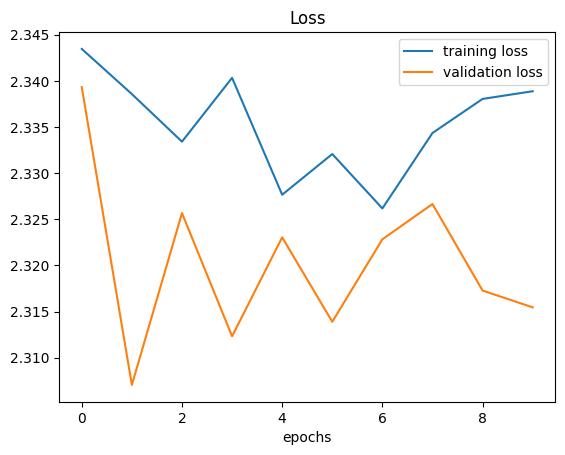

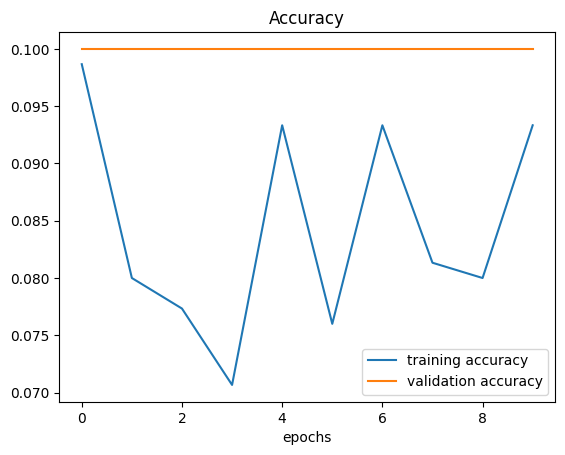

In [103]:
plot_loss_curves(efficientnet_history)

## Different types of transfer learning

* Using an existing model with no changes
* Using the prelearned patterns of an existing model (Feature extraction)
* Use the prelearned patterns of an existing model and "fine-tune" many or all of the underlying layers (fine-tuning)